El objetivo de este notebook es hacer una exploracion a la base datos y determinar limpieza e imputación de datos

se crea un entorno para manejar versionamiento de librerias, para entre proyecto se crea desde cmd:
- py -m venv venv
se activa:
- source venv/Scripts/activate


Descripción:
El objetivo del proyecto es poder predecir el % de churn del cliente  para una empresa lider en mensajeria, aplicando tecnicas estadisticas y modelos de machine learning.

#Carga de librerias requeridas

In [1]:
import pandas as pd # Manejo y analisis de datos
import io # Manejo de archivos en memoria

import matplotlib.pyplot as plt # Crear graficos basicos
import seaborn as sns # Crear graficos estadisticos mas bonitos


# Carga y exploracion de los datos

Se verifica que cada registros esta entre comillas dobles, por ende por cada linea se eliminan espacios, saltos y comillas dobles y finalmente se recontruye el contenido para leerlo en un df

In [2]:
with open("../database/bronze/raw_data/raw_data_customers.csv", "r", encoding="utf-8") as f:
    clean_lines = [line.strip().strip('"') for line in f]
 
df = pd.read_csv(io.StringIO("\n".join(clean_lines)))
df.head()

,customer_id,full_name,email,phone,signup_date,last_purchase_date,monthly_spend,total_shipments,churn_label,home_address
0,C001,Juan Perez,jperez@email.com,555-0101,2023-01-15,12/05/2025,450.5,12.0,0.0,Calle Falsa 123
1,C002,Maria Garcia,m.garcia@provider.net,555-0102,2023-02-20,2025-05-10,1200.0,45.0,0.0,Carrera 7 # 45-10
2,C003,Carlos Rodriguez,c.rod@work.com,NaN,2023-03-05,03/25/2025,NaN,8.0,1.0,Av. Siempre Viva 742
3,C004,Ana Martinez,ana.mtz@mail.com,555-0104,2023-04-12,2025-06-01,890.2,22.0,0.0,Clle 100 # 15
4,C001,Juan Perez,jperez@email.com,555-0101,2023-01-15,12/05/2025,450.5,12.0,0.0,Calle Falsa 123


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         114 non-null    str    
 1   full_name           114 non-null    str    
 2   email               114 non-null    str    
 3   phone               112 non-null    str    
 4   signup_date         114 non-null    str    
 5   last_purchase_date  113 non-null    str    
 6   monthly_spend       98 non-null     float64
 7   total_shipments     112 non-null    float64
 8   churn_label         113 non-null    float64
 9   home_address        106 non-null    str    
dtypes: float64(3), str(7)
memory usage: 9.0 KB


Se observar las variables, el tipo de dato y la canitad de registros por cada variable

In [4]:
df.isnull().mean().round(4)*100 

customer_id            0.00
full_name              0.00
email                  0.00
phone                  1.75
signup_date            0.00
last_purchase_date     0.88
monthly_spend         14.04
total_shipments        1.75
churn_label            0.88
home_address           7.02
dtype: float64

Se verifica % de participacion de datos nulos por cada variable, sin embargo, se pueden presentar valores nulos como texto por ende es recomendable estandarizar de valores nulos

In [5]:
#Verificación de los primeros 5 valores unicos por cada variables
columns_str = df.select_dtypes(include=["object","string"]).columns

for col in columns_str:
    n = df[col].nunique(dropna=False)
    print(f"{col}")
    if n<=15:
        print(df[col].value_counts(dropna=False))
    else:
        print(df[col].dropna().unique()[:5], "...")


customer_id
<StringArray>
['C001', 'C002', 'C003', 'C004', 'C005']
Length: 5, dtype: str ...
full_name
<StringArray>
[      'Juan Perez',     'Maria Garcia', 'Carlos Rodriguez',
     'Ana Martinez',     'Luis Herrera']
Length: 5, dtype: str ...
email
<StringArray>
[     'jperez@email.com', 'm.garcia@provider.net',        'c.rod@work.com',
      'ana.mtz@mail.com',   'lherrera@domain.org']
Length: 5, dtype: str ...
phone
<StringArray>
['555-0101', '555-0102', '555-0104', '555-0105', '555-0106']
Length: 5, dtype: str ...
signup_date
<StringArray>
['2023-01-15', '2023-02-20', '2023-03-05', '2023-04-12', '2023-05-30']
Length: 5, dtype: str ...
last_purchase_date
<StringArray>
['12/05/2025', '2025-05-10', '03/25/2025', '2025-06-01', '2024-12-20']
Length: 5, dtype: str ...
home_address
<StringArray>
[     'Calle Falsa 123',    'Carrera 7 # 45-10', 'Av. Siempre Viva 742',
        'Clle 100 # 15',      'Apt 502 Torre B']
Length: 5, dtype: str ...


In [6]:
columns_num = df.select_dtypes(include=["int","float"]).columns

for col in columns_num:
    n = df[col].nunique(dropna=False)
    print(f"{col}")
    if n<=15:
        print(df[col].value_counts(dropna=False))
    else:
        print(df[col].dropna().unique()[:8], "...")


monthly_spend
[ 4.5050e+02  1.2000e+03  8.9020e+02  3.1000e+02  2.5000e+03  1.5000e+02
  9.9999e+04 -5.0000e+01] ...
total_shipments
[12. 45.  8. 22.  5.  2. 15. 10.] ...
churn_label
churn_label
0.0    85
1.0    28
NaN     1
Name: count, dtype: int64


se puede observar que las columnas signup_date y last_purchase_date son fechas el cual contienen diferentes formatos por ende toca aplicar estandarizacion de fecha

In [7]:
df["signup_date"].unique()

<StringArray>
['2023-01-15', '2023-02-20', '2023-03-05', '2023-04-12', '2023-05-30',
 '21/06/2023', '2023-07-02', '2023-08-14', '2023-09-01', '2023-10-10',
 '2023-11-01', '2023-11-15', '2023-12-01', '2024-01-05', '2024-01-20',
 '2024-02-10', '2024-02-28', '2024-03-12', '2024-03-25', '2024-04-05',
 '2024-04-15', '12/05/2024', '2024-05-20', '2024-06-01', '2024-06-15',
 '2024-07-01', '2024-07-10', '2024-07-25', '2024-08-05', '2024-08-15',
 '2024-09-01', '2024-09-15', '2024-10-01', '2024-10-15', '2024-11-01',
 '2024-11-15', '2024-12-01', '2024-12-15', '2025-01-05', '05/01/2025',
 '2025-01-20', '2025-02-01', '2025-02-15', '2025-03-01', '2025-03-10',
 '2025-03-20', '2025-04-01', '2025-04-10', '2025-04-20', '2025-05-01',
 '2025-05-10', '2023-01-01', '2023-02-10', '2023-03-15', '2023-04-01',
 '2023-05-10', '2023-06-01', '2023-07-01', '2023-08-15', '2023-11-20',
 '2023-12-05', '2024-01-15', '26/05/2024', '2024-03-01', '2024-04-12',
 '2024-05-01', '2024-06-20', '2024-07-15', '2024-09-10', '2024-

In [8]:
df["last_purchase_date"].unique()

<StringArray>
['12/05/2025', '2025-05-10', '03/25/2025', '2025-06-01', '2024-12-20',
 '2025-04-15',          nan, '2025-05-28', '2025-01-10', '10/10/2024',
 '2025-05-20', '15/06/2025', '05/05/2025', '2025-06-02', '2025-04-12',
 '28/05/2025', '2025-03-15', '2025-05-30', '05/06/2025', '2025-02-10',
 '20/05/2025', '2025-01-05', '2025-06-10', '01/05/2025', '2025-05-25',
 '25/03/2025', '2025-04-20', '01/01/2025', '2025-06-12', '2025-05-18',
 '2025-04-30', '2025-05-22', '01/06/2025', '2025-02-14', '2025-06-15',
 '20/06/2025', '10/06/2025', '2025-05-15', '2025-06-05', '2025-06-20',
 '10/05/2024', '15/05/2025', '2025-05-26', '2023-12-30', '10/05/2025',
 '30/05/2025', '2025-01-15', '2024-12-31', '2025-03-20', '12/12/2024',
 '15/04/2025', '2024-11-30', '12/06/2025', '2024-12-15']
Length: 54, dtype: str

In [9]:
# verificando la descripcion general de todas las variables
df.describe(include="all")

,customer_id,full_name,email,phone,signup_date,last_purchase_date,monthly_spend,total_shipments,churn_label,home_address
count,114,114,114,112,114,113,98.000000,112.000000,113.000000,106
unique,110,110,110,109,96,53,NaN,NaN,NaN,95
top,C001,Juan Perez,jperez@email.com,555-0101,2023-01-15,2025-06-01,NaN,NaN,NaN,Santa Marta
freq,2,2,2,2,3,9,NaN,NaN,NaN,3
mean,NaN,NaN,NaN,NaN,NaN,NaN,5583.346429,58.928571,0.247788,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,19690.153720,119.059279,0.433651,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,-100.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,412.500000,10.000000,0.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,850.000000,22.000000,0.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2150.000000,50.000000,0.000000,NaN


Hay 114 filas, pero solo 110 registros con customer_id unico, adicional se puede ver que hay variables PII como full_name, email, phone y home_address

In [10]:
print(f"% de valores duplicados del df por customer_id es de: {df.duplicated(subset=["customer_id"]).mean().round(4) * 100}%")

% de valores duplicados del df por customer_id es de: 3.51%


In [11]:
# Validación de valores duplicados por customer_id
valores_duplicados = df[df.duplicated(subset=["customer_id"],keep=False)].sort_values("customer_id") 
valores_duplicados.head(20)

,customer_id,full_name,email,phone,signup_date,last_purchase_date,monthly_spend,total_shipments,churn_label,home_address
0,C001,Juan Perez,jperez@email.com,555-0101,2023-01-15,12/05/2025,450.5,12.0,0.0,Calle Falsa 123
4,C001,Juan Perez,jperez@email.com,555-0101,2023-01-15,12/05/2025,450.5,12.0,0.0,Calle Falsa 123
2,C003,Carlos Rodriguez,c.rod@work.com,NaN,2023-03-05,03/25/2025,NaN,8.0,1.0,Av. Siempre Viva 742
8,C003,Carlos Rodriguez,c.rod@work.com,NaN,2023-03-05,03/25/2025,99999.0,8.0,1.0,Av. Siempre Viva 742
13,C012,Beatriz Pinzón,b.pinzon@eco.com,555-0112,2023-11-15,15/06/2025,850.0,30.0,0.0,Av. Jimenez 10
22,C012,Beatriz Pinzón,b.pinzon@eco.com,555-0112,2023-11-15,15/06/2025,850.0,30.0,0.0,Av. Jimenez 10
25,C023,Nairo Quintana,n.quintana@ciclismo.co,555-0123,2024-05-20,20/05/2025,99999.0,50.0,0.0,Boyacá Libre
43,C023,Nairo Quintana,n.quintana@ciclismo.co,555-0123,2024-05-20,20/05/2025,99999.0,50.0,0.0,Boyacá Libre


Se observa que puede ser una inconsistenca en la base de datos ya que los duplicado son exactamente iguales, adicional solo representan el 3.51% de regitros lo cual no generara impacto, por ende, se debe proceder a eliminar los duplicados dejando los registros que menos contengan nulos.

In [12]:
# Se valida las variables con datos sensibles
variables_sensibles = df[["customer_id","full_name", "email", "phone", "home_address"]]
variables_sensibles

,customer_id,full_name,email,phone,home_address
0,C001,Juan Perez,jperez@email.com,555-0101,Calle Falsa 123
1,C002,Maria Garcia,m.garcia@provider.net,555-0102,Carrera 7 # 45-10
2,C003,Carlos Rodriguez,c.rod@work.com,NaN,Av. Siempre Viva 742
3,C004,Ana Martinez,ana.mtz@mail.com,555-0104,Clle 100 # 15
4,C001,Juan Perez,jperez@email.com,555-0101,Calle Falsa 123
...,...,...,...,...,...
109,C106,Simón Bolivar,s.bolivar@libertador.co,555-0206,Santa Marta
110,C107,Tirso Duarte,t.duarte@timba.cu,555-0207,Cali Valle
111,C108,Uriel Henao,u.henao@corrido.co,555-0208,Boyacá
112,C109,Vasco Nuñez,v.nuñez@balboa.es,555-0209,Darien


Se debe proceder a anonimiza la variable customer_id para conservar la trazabilidad de cada cliente sin exponer su identificador original. Esto permite mantener una referencia unica para auditorias, validaciones o cruces internos, reduciendo el riesgo de identificacion directa, adicional de debe proceder a elimiar las variables "full_name", "email", "phone", "home_address", ya que contienen informacion personal del cliente y no son necesarias para el analisis

In [13]:
#Variables no sensibles
df_sin_sensibles = df[[col for col in df.columns if col not in variables_sensibles]]
df_sin_sensibles.head()

,signup_date,last_purchase_date,monthly_spend,total_shipments,churn_label
0,2023-01-15,12/05/2025,450.5,12.0,0.0
1,2023-02-20,2025-05-10,1200.0,45.0,0.0
2,2023-03-05,03/25/2025,NaN,8.0,1.0
3,2023-04-12,2025-06-01,890.2,22.0,0.0
4,2023-01-15,12/05/2025,450.5,12.0,0.0


In [14]:
#Distribucion de la variable objetivo
df_sin_sensibles["churn_label"].value_counts(dropna=False,normalize=True).round(4)*100

churn_label
0.0    74.56
1.0    24.56
NaN     0.88
Name: proportion, dtype: float64

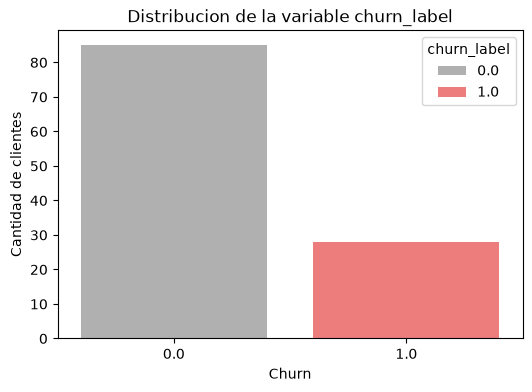

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_sin_sensibles[df_sin_sensibles["churn_label"].notna()],x="churn_label", palette=["#B0B0B0", "#FF6B6B"],hue="churn_label")
plt.title("Distribucion de la variable churn_label")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")
plt.show()

se puede observar que existe desbalanceo en la variable objetivo, lo que podria generar que el modelo aprenda con mayor facilidad la clase mayoritaria y tener un bajo desempeño al clasificar clientes con churn, Por ende, sera necesario aplicar tecnicas de balanceo de clases, como sobremuestreo, submuestreo o metodos como SMOTE, con el fin de mejorar la capacidad del modelo para reconocer ambas clases de manera equilibrada, adicional se observar que menos del 1% es null por lo que se debe proceder a eliminar esos registros dado a que no es posible imputar la variable objetivo

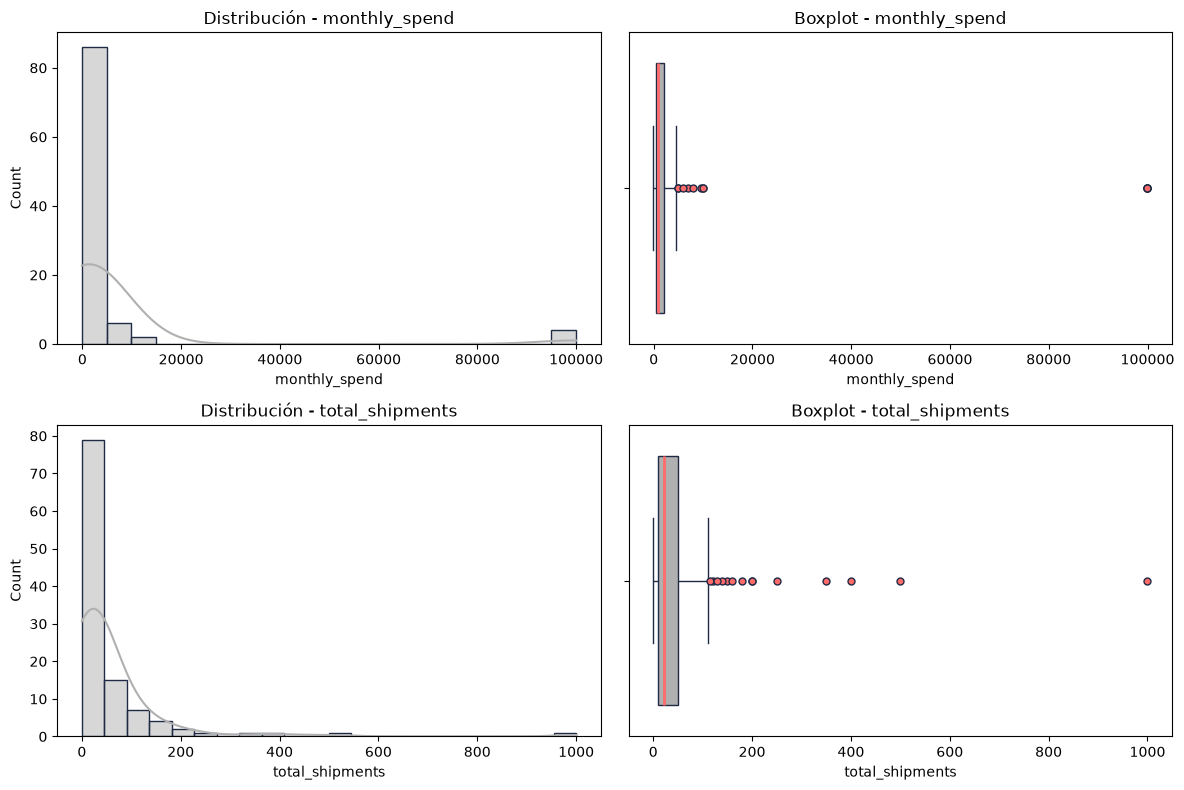

In [16]:
fig, axes = plt.subplots(2,2,figsize=(12, 8))

sns.histplot(df_sin_sensibles["monthly_spend"].dropna(),kde=True,ax=axes[0, 0],color="#B0B0B0",edgecolor="#1F2A44")
axes[0,0].set_title("Distribución - monthly_spend")
sns.boxplot(x=df_sin_sensibles["monthly_spend"].dropna(),ax=axes[0, 1],color= "#B0B0B0", boxprops={"edgecolor": "#1F2A44"},
        whiskerprops={"color": "#1F2A44"},capprops={"color": "#1F2A44"},medianprops={"color": "#FF6B6B", "linewidth": 2},
        flierprops={
            "marker": "o",
            "markerfacecolor": "#FF6B6B",
            "markeredgecolor": "#1F2A44",
            "markersize": 5
        })
axes[0,1].set_title("Boxplot - monthly_spend")
sns.histplot(df_sin_sensibles["total_shipments"].dropna(), kde=True, ax=axes[1, 0],color="#B0B0B0",edgecolor="#1F2A44")
axes[1, 0].set_title("Distribución - total_shipments")
sns.boxplot(x=df_sin_sensibles["total_shipments"].dropna(), ax=axes[1, 1],color= "#B0B0B0", boxprops={"edgecolor": "#1F2A44"},
        whiskerprops={"color": "#1F2A44"},capprops={"color": "#1F2A44"},medianprops={"color": "#FF6B6B", "linewidth": 2},
        flierprops={
            "marker": "o",
            "markerfacecolor": "#FF6B6B",
            "markeredgecolor": "#1F2A44",
            "markersize": 5
        })
axes[1,1].set_title("Boxplot - total_shipments")
plt.tight_layout()
plt.show()

Se observa que las variables monthly_spend y total_shipments presentan una distribucion asimetrica positiva con sesgo a la derecha. La mayoria de los registros se concentran en valores bajos, mientras que existen algunos valores extremadamente altos que podrian corresponder a valores atipicos.

En los boxplot se observa que la mayor parte de los registros presentan valores bajos tanto en el gasto mensual (monthly_spend) como en la cantidad de envios (total_shipments). Asimismo, en ambas variables se identifican multiples valores atipicos, algunos de ellos considerablemente alejados del resto de las observaciones. Estos valores pueden incrementar la media y la variabilidad de los datos, además de influir en el desempeño de algunos modelos de aprendizaje automatico sensibles a los valores extremos. Sin embargo, antes de decidir su eliminacion o tratamiento, es fundamental verificar si corresponden a errores de captura o a comportamientos reales del negocio, para lo cual es indispensable contar con conocimiento del dominio y validar la informacion con las areas responsables.

En las distribuciones se observa que las variables monthly_spend y total_shipments presentan una distribucion asimetrica positiva con sesgo a la derecha. La mayoria de los registros se concentran en valores bajos, mientras que existen algunos valores extremadamente altos que podrian corresponder a valores atipicos.

In [17]:
#Validar el maximo y minimo de variables numericas
max_spend = df["monthly_spend"].max()
max_shipments = df["total_shipments"].max()
min_spend = df["monthly_spend"].min()
min_shipments = df["total_shipments"].min()
print(f"valor maximo de spend: {max_spend}, valor minimo: {min_spend}")
print(f"valor maximo de shipment: {max_shipments}, valor minimo: {min_shipments}")

valor maximo de spend: 99999.0, valor minimo: -100.0
valor maximo de shipment: 1000.0, valor minimo: 0.0


In [18]:
#validar los registros atipicos cola derecha de monthly_spend
Q1 = df["monthly_spend"].quantile(0.25)
Q3 = df["monthly_spend"].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR
df[df["monthly_spend"] > limite_superior]
df.loc[df["monthly_spend"] > limite_superior]

,customer_id,full_name,email,phone,signup_date,last_purchase_date,monthly_spend,total_shipments,churn_label,home_address
8,C003,Carlos Rodriguez,c.rod@work.com,NaN,2023-03-05,03/25/2025,99999.0,8.0,1.0,Av. Siempre Viva 742
25,C023,Nairo Quintana,n.quintana@ciclismo.co,555-0123,2024-05-20,20/05/2025,99999.0,50.0,0.0,Boyacá Libre
43,C023,Nairo Quintana,n.quintana@ciclismo.co,555-0123,2024-05-20,20/05/2025,99999.0,50.0,0.0,Boyacá Libre
49,C046,Karol G,k.g@bichota.com,555-0146,2025-03-20,20/06/2025,5000.0,150.0,0.0,Provenza
57,C054,Shakira Mebarak,s.mebarak@global.com,555-0154,2023-03-15,2025-06-20,10000.0,400.0,0.0,Barranquilla Patios
65,C062,Abelardo De La Espriella,a.espriella@law.co,555-0162,2023-11-20,20/06/2025,7000.0,200.0,0.0,Miami Brickell
66,C063,Bruno Mars,b.mars@vegas.us,555-0163,2023-12-05,05/06/2025,99999.0,90.0,0.0,Las Vegas Strip
68,C065,Diomedes Diaz,d.diaz@cacique.co,555-0165,26/05/2024,2025-05-26,5000.0,200.0,0.0,La Junta
70,C067,Falcao Garcia,f.garcia@tiger.co,555-0167,2024-03-01,01/06/2025,6000.0,180.0,0.0,Santa Marta Beach
74,C071,James Rodriguez,j.rodriguez@10.co,555-0171,2024-07-15,15/06/2025,8000.0,250.0,0.0,Envigado


In [19]:
print(f"total de valores atipicos de monthly_spend cola dereha: {df.loc[df["monthly_spend"] > limite_superior].shape[0]}")

total de valores atipicos de monthly_spend cola dereha: 12


In [20]:
#validar los registros atipicos cola derecha de shipments
Q1 = df["total_shipments"].quantile(0.25)
Q3 = df["total_shipments"].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR
df[df["total_shipments"] > limite_superior]
df.loc[df["total_shipments"] > limite_superior]


,customer_id,full_name,email,phone,signup_date,last_purchase_date,monthly_spend,total_shipments,churn_label,home_address
11,C010,Martha Lucía,mlucia@xyz.com,555-0110,2023-10-10,10/10/2024,420.0,1000.0,NaN,NaN
49,C046,Karol G,k.g@bichota.com,555-0146,2025-03-20,20/06/2025,5000.0,150.0,0.0,Provenza
51,C048,Mario Hernandez,m.hernandez@cuero.co,555-0148,2025-04-10,10/06/2025,3500.0,120.0,0.0,Andino Shopping
57,C054,Shakira Mebarak,s.mebarak@global.com,555-0154,2023-03-15,2025-06-20,10000.0,400.0,0.0,Barranquilla Patios
65,C062,Abelardo De La Espriella,a.espriella@law.co,555-0162,2023-11-20,20/06/2025,7000.0,200.0,0.0,Miami Brickell
68,C065,Diomedes Diaz,d.diaz@cacique.co,555-0165,26/05/2024,2025-05-26,5000.0,200.0,0.0,La Junta
70,C067,Falcao Garcia,f.garcia@tiger.co,555-0167,2024-03-01,01/06/2025,6000.0,180.0,0.0,Santa Marta Beach
71,C068,Greeicy Rendon,g.rendon@music.co,555-0168,2024-04-12,2025-06-15,3200.0,115.0,0.0,Cali Chipichape
74,C071,James Rodriguez,j.rodriguez@10.co,555-0171,2024-07-15,15/06/2025,8000.0,250.0,0.0,Envigado
77,C074,Maluma Baby,m.baby@reggaeton.co,555-0174,2024-10-25,2025-06-20,9500.0,350.0,0.0,Medellin Antioquia


In [21]:
print(f"total de valores atipicos de shipments cola dereha: {df.loc[df["total_shipments"] > limite_superior].shape[0]}")

total de valores atipicos de shipments cola dereha: 14


Al revisar los valores minimos, maximos y los registros identificados mediante el criterio del rango intercuartilico, se pueden observar posibles inconsistencias en las variables analizadas. En monthly_spend se observa como valor minimo un valor negativo de -100, el cual podria corresponder a un error de captura o una devolucion. Asimismo, el valor 99999 se repite en varios registros y presenta poca coherencia con la cantidad de envios de algunos clientes, por lo que debe validarse con el area de negocio. En total_shipments se identifico un maximo de 1000 envios asociado a un gasto mensual de 420, combinacion que tambien requiere revision. Para efectos de la prueba se asumira que fueron errores por lo que se considera reemplazar esos valores con 0 para tratamiento